In [23]:
import numpy as np
from dual_pol import *
import matplotlib.pyplot as plt

In [5]:
metadata = _get_nexrad_reflectivity_ppi_data()
rgba = _reflectivity_dbz_to_rgba(
    metadata["reflectivity_dbz"],
    valid_mask=metadata["valid_mask"],
    vmin=metadata["vmin"],
    vmax=metadata["vmax"],
)

In [31]:
angle = 0  # deg
angle_idx = np.nanargmin(np.abs(metadata["azimuth_grid_deg"][0] - angle))
angle_idx

np.int64(600)

(0.0, 360.0)

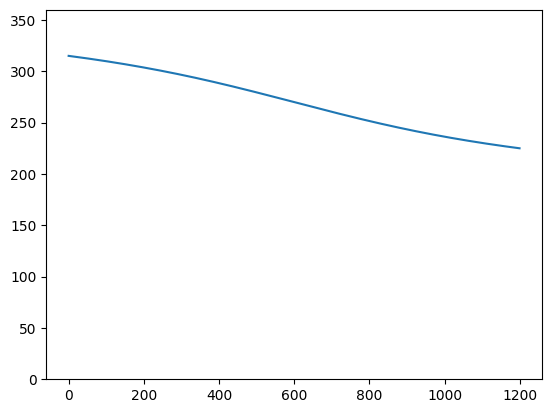

In [41]:
plt.plot(metadata["azimuth_grid_deg"][:, 0])
plt.ylim(0, 360)

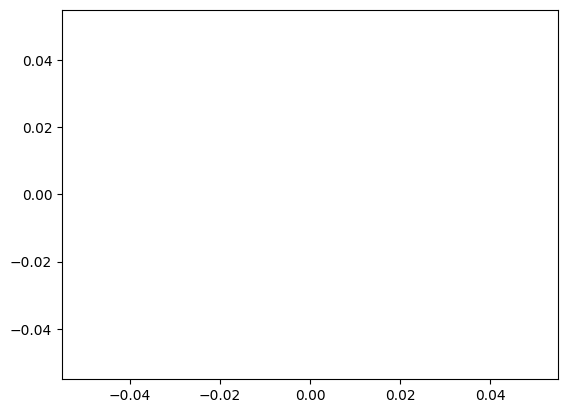

In [ ]:

z = metadata["reflectivity_dbz"][angle_idx]
r = metadata["range_grid_km"][angle_idx]

plt.plot(r, z)

In [20]:
metadata

{'station': 'KTLX',
 'scan_time': '2024-05-07 02:38:11 UTC',
 'elevation_deg': 1.32,
 'vcp_pattern': 212,
 'sweep': 6,
 'max_range_km': 150.0,
 'vmin': -20.0,
 'vmax': 75.0,
 'source': 'Unidata NEXRAD Level II archive on AWS S3',
 'reflectivity_dbz': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(1200, 1200), dtype=float32),
 'valid_mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],
       shape=(1200, 1200)),
 'azimuth_grid_deg': arra

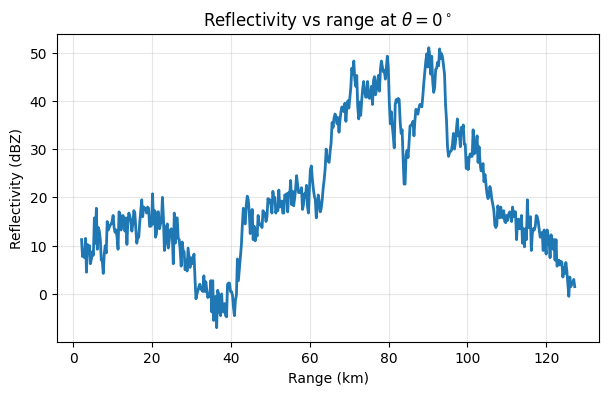

In [44]:
theta = 90.0  # degrees, north
# 1200 is even, so x=0 lies between two columns; average the two closest
x0 = np.argsort(np.abs(metadata["x_coords_km"]))[:2]
north = metadata["y_coords_km"] >= 0
r = metadata["range_grid_km"][north][:, x0].mean(axis=1)
z = np.nanmean(metadata["reflectivity_dbz"][north][:, x0], axis=1)
valid = np.any(metadata["valid_mask"][north][:, x0], axis=1)
order = np.argsort(r)
r = r[order]
z = z[order]
valid = valid[order]
plt.figure(figsize=(7, 4))
plt.plot(r[valid], z[valid], lw=2)
plt.xlabel("Range (km)")
plt.ylabel("Reflectivity (dBZ)")
plt.title(r"Reflectivity vs range at $\theta = 0^\circ$")
plt.grid(alpha=0.3)

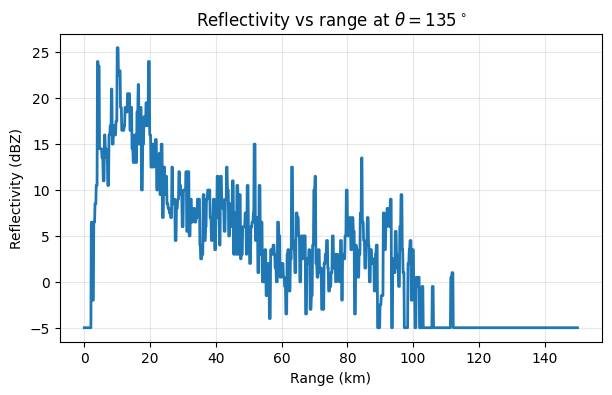

In [49]:
theta = 135.0  # degrees, 0=north, 90=east
max_range = metadata["max_range_km"]
# sample points along the desired radial
r = np.linspace(0, max_range, 1200)
# convert polar -> Cartesian using your azimuth convention
# x points east, y points north
x = r * np.sin(np.deg2rad(theta))
y = r * np.cos(np.deg2rad(theta))
# nearest-neighbor lookup into the gridded raster
x_idx = np.abs(metadata["x_coords_km"][None, :] - x[:, None]).argmin(axis=1)
y_idx = np.abs(metadata["y_coords_km"][None, :] - y[:, None]).argmin(axis=1)
z = metadata["reflectivity_dbz"][y_idx, x_idx]
z = np.nan_to_num(z, nan=-5)
valid = metadata["valid_mask"][y_idx, x_idx]
plt.figure(figsize=(7, 4))
plt.plot(r, z, lw=2)
plt.xlabel("Range (km)")
plt.ylabel("Reflectivity (dBZ)")
plt.title(rf"Reflectivity vs range at $\theta = {theta:.0f}^\circ$")
plt.grid(alpha=0.3)